<a href="https://colab.research.google.com/github/ELOUARDIMustapha/fake-news-app/blob/main/mon_projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Importation**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile

# Chemin vers le zip directement dans Drive
zip_path = '/content/drive/MyDrive/mon_projet/dataset_fake_news.zip'
extract_path = '/content/dataset'  # Où tu veux extraire dans Colab

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction terminée !")


Extraction terminée !


In [ ]:
import pandas as pd

fake = pd.read_csv(f"{extract_path}/Fake.csv")
true = pd.read_csv(f"{extract_path}/True.csv")

In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


# **Data Preprocessing**

In [ ]:
print(fake.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')


In [ ]:
fake['label']=0

In [ ]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
true.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [ ]:
true['label']=1

In [ ]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [ ]:
fake.drop(columns=["title", "subject", "date"], inplace=True)
true.drop(columns=["title", "subject", "date"], inplace=True)

In [ ]:
df = pd.concat([fake, true], axis=0).reset_index(drop=True)

In [ ]:
df.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


In [ ]:
df.isnull().sum()

,0
text,0
label,0


In [ ]:
print(df.duplicated().sum())  # Nombre de doublons
df.drop_duplicates(inplace=True)  # Supprimer les doublons


6251


In [ ]:
df.head()  # Afficher les premières lignes


,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [ ]:
df["text_length"] = df["text"].apply(len)
print(df["text_length"].describe())  # Statistiques sur la longueur des textes


count    38647.000000
mean      2455.824540
std       1936.624786
min          1.000000
25%       1318.000000
50%       2227.000000
75%       3096.000000
max      51794.000000
Name: text_length, dtype: float64


In [ ]:
print(df[df["text_length"] < 10])

           text  label  text_length
10923                0            1
11117    Enjoy:      0            6
11685    Watch:      0            6
11796   Watch:       0            7
11847  Via: NPR      0            8
12012   Via: WT      0            7
12063    Enjoy       0            6
12244                0            2
12333     Ouch!      0            5
12570  Via: TMZ      0            8
12725   Via: GP      0            7
32451                1            1


In [ ]:
df = df[df["text_length"] > 10]  # Garde uniquement les textes avec plus de 10 caractères
df.reset_index(drop=True, inplace=True)  # Réinitialise l'index après suppression


In [ ]:
print(df["text_length"].describe())  # Vérifier les nouvelles statistiques
print(df[df["text_length"] < 10])  # Vérifier s'il reste des textes trop courts


count    38633.000000
mean      2456.712318
std       1936.413948
min         11.000000
25%       1319.000000
50%       2228.000000
75%       3096.000000
max      51794.000000
Name: text_length, dtype: float64
Empty DataFrame
Columns: [text, label, text_length]
Index: []


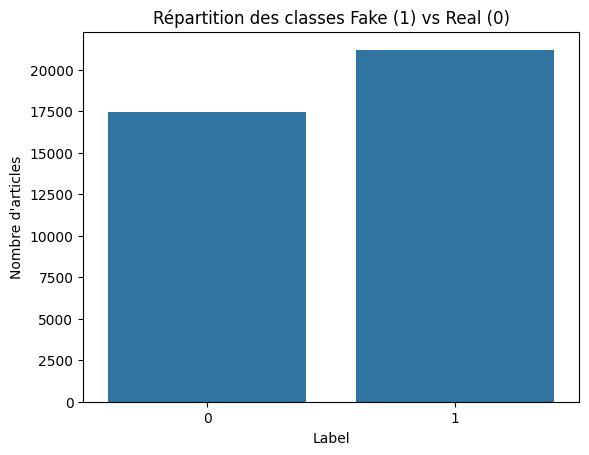

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisation de la répartition des classes
sns.countplot(x=df["label"])
plt.title("Répartition des classes Fake (1) vs Real (0)")
plt.xlabel("Label")
plt.ylabel("Nombre d'articles")
plt.show()


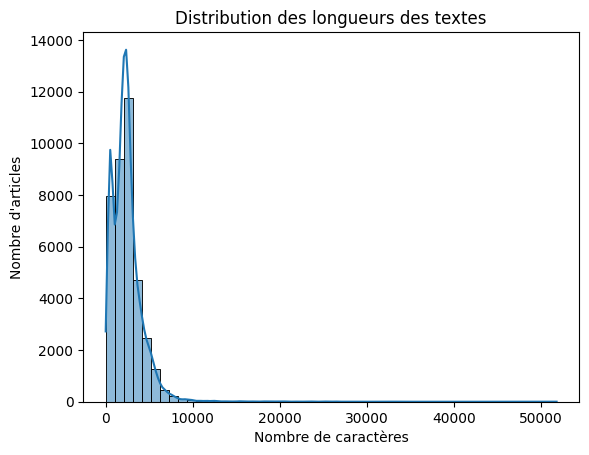

In [ ]:
sns.histplot(df["text_length"], bins=50, kde=True)
plt.title("Distribution des longueurs des textes")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre d'articles")
plt.show()


In [ ]:
print(df[df["text_length"] > 50000].shape)

(1, 3)


In [ ]:
# Exemple de Fake News
print("🔴 FAKE NEWS EXAMPLE:")
print(df[df["label"] == 1]["text"].iloc[0][:500])  # Affiche les 500 premiers caractères

# Exemple de Real News
print("\n🟢 REAL NEWS EXAMPLE:")
print(df[df["label"] == 0]["text"].iloc[0][:500])  # Affiche les 500 premiers caractères


🔴 FAKE NEWS EXAMPLE:
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they retur

🟢 REAL NEWS EXAMPLE:
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  Presi

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))  # Liste des mots courants en anglais

# Fonction de nettoyage du texte
def clean_text(text):
    text = text.lower()  # Convertir en minuscule
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Supprimer les liens
    text = re.sub(r'\d+', '', text)  # Supprimer les chiffres
    text = ''.join([c for c in text if c not in string.punctuation])  # Supprimer la ponctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Supprimer les stopwords
    return " ".join(words)

# Appliquer le nettoyage sur la colonne "text"
df["clean_text"] = df["text"].apply(clean_text)

# Vérifier un exemple avant/après
print("Avant nettoyage :", df["text"].iloc[0][:300])
print("\nAprès nettoyage :", df["clean_text"].iloc[0][:300])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Avant nettoyage : Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger a

Après nettoyage : donald trump wish americans happy new year leave instead give shout enemies haters dishonest fake news media former reality show star one job country rapidly grows stronger smarter want wish friends supporters enemies haters even dishonest fake news media happy healthy new year president angry pants


In [ ]:
# Récupérer tous les mots
all_words = []
df["text"].apply(lambda x: all_words.extend(clean_text(x).split()))

# Compter les mots les plus fréquents
word_freq = Counter(all_words)
most_common_words = word_freq.most_common(20)

# Afficher les résultats
print("🔠 Mots les plus fréquents :")
for word, count in most_common_words:
    print(f"{word}: {count}")

🔠 Mots les plus fréquents :
said: 120677
trump: 105364
us: 54955
would: 49197
president: 44100
people: 35091
one: 29769
reuters: 28223
state: 27199
also: 27007
new: 26754
donald: 25101
house: 24105
government: 23415
states: 22888
republican: 22885
united: 21206
could: 21179
told: 20642
clinton: 20430


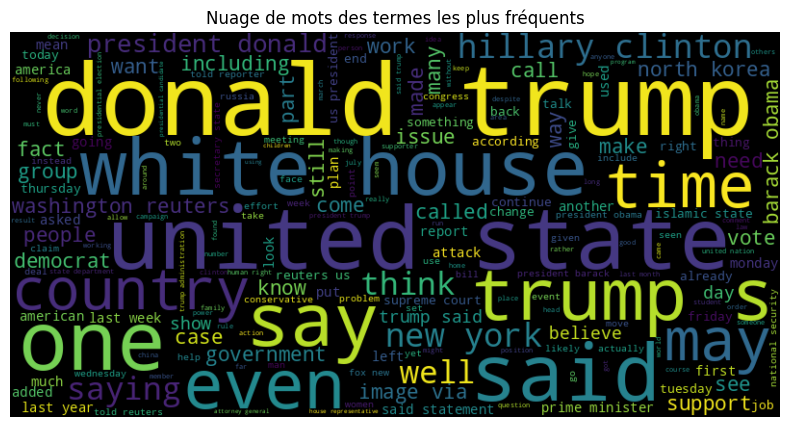

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convertir les mots en une seule grande chaîne de texte
all_text = " ".join(all_words)

# Créer le word cloud
wordcloud = WordCloud(width=800, height=400, background_color="black").generate(all_text)

# Afficher l'image
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Cacher les axes
plt.title("Nuage de mots des termes les plus fréquents")
plt.show()


<ipython-input-31-046373af6033>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Fréquence", y="Mot", data=word_freq_df, palette="viridis")


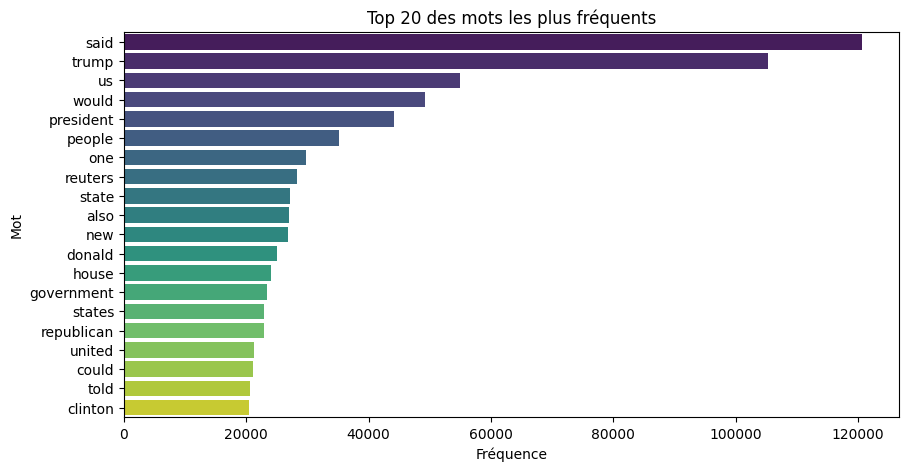

In [ ]:
import seaborn as sns
import pandas as pd

# Transformer les mots fréquents en DataFrame pour Seaborn
word_freq_df = pd.DataFrame(most_common_words, columns=["Mot", "Fréquence"])

# Afficher le graphique en barres
plt.figure(figsize=(10, 5))
sns.barplot(x="Fréquence", y="Mot", data=word_freq_df, palette="viridis")
plt.title("Top 20 des mots les plus fréquents")
plt.xlabel("Fréquence")
plt.ylabel("Mot")
plt.show()


In [ ]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
nltk.download('punkt')

# Tokenizer chaque texte
df["tokens"] = df["clean_text"].apply(word_tokenize)

# Voir un exemple
print(df["tokens"].iloc[0])


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


['donald', 'trump', 'wish', 'americans', 'happy', 'new', 'year', 'leave', 'instead', 'give', 'shout', 'enemies', 'haters', 'dishonest', 'fake', 'news', 'media', 'former', 'reality', 'show', 'star', 'one', 'job', 'country', 'rapidly', 'grows', 'stronger', 'smarter', 'want', 'wish', 'friends', 'supporters', 'enemies', 'haters', 'even', 'dishonest', 'fake', 'news', 'media', 'happy', 'healthy', 'new', 'year', 'president', 'angry', 'pants', 'tweeted', 'great', 'year', 'america', 'country', 'rapidly', 'grows', 'stronger', 'smarter', 'want', 'wish', 'friends', 'supporters', 'enemies', 'haters', 'even', 'dishonest', 'fake', 'news', 'media', 'happy', 'healthy', 'new', 'year', 'great', 'year', 'america', 'donald', 'j', 'trump', 'realdonaldtrump', 'december', 'trump', 'tweet', 'went', 'welll', 'expectwhat', 'kind', 'president', 'sends', 'new', 'year', 'greeting', 'like', 'despicable', 'petty', 'infantile', 'gibberish', 'trump', 'lack', 'decency', 'even', 'allow', 'rise', 'gutter', 'long', 'enough

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# Appliquer la lemmatisation
df["lemmas"] = df["tokens"].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

# Voir un exemple
print(df["lemmas"].iloc[0])


[nltk_data] Downloading package wordnet to /root/nltk_data...


['donald', 'trump', 'wish', 'american', 'happy', 'new', 'year', 'leave', 'instead', 'give', 'shout', 'enemy', 'hater', 'dishonest', 'fake', 'news', 'medium', 'former', 'reality', 'show', 'star', 'one', 'job', 'country', 'rapidly', 'grows', 'stronger', 'smarter', 'want', 'wish', 'friend', 'supporter', 'enemy', 'hater', 'even', 'dishonest', 'fake', 'news', 'medium', 'happy', 'healthy', 'new', 'year', 'president', 'angry', 'pant', 'tweeted', 'great', 'year', 'america', 'country', 'rapidly', 'grows', 'stronger', 'smarter', 'want', 'wish', 'friend', 'supporter', 'enemy', 'hater', 'even', 'dishonest', 'fake', 'news', 'medium', 'happy', 'healthy', 'new', 'year', 'great', 'year', 'america', 'donald', 'j', 'trump', 'realdonaldtrump', 'december', 'trump', 'tweet', 'went', 'welll', 'expectwhat', 'kind', 'president', 'sends', 'new', 'year', 'greeting', 'like', 'despicable', 'petty', 'infantile', 'gibberish', 'trump', 'lack', 'decency', 'even', 'allow', 'rise', 'gutter', 'long', 'enough', 'wish', '

In [ ]:
df['text_lemmatized'] = df.lemmas.apply(lambda list: ' '.join(list))

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAXLEN = 300
MAX_WORDS = 10000

# Créer le tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text_lemmatized'])

# Transformer les textes en séquences
sequences = tokenizer.texts_to_sequences(df['text_lemmatized'])

# Appliquer le padding
padded_sequences = pad_sequences(sequences, maxlen=MAXLEN)

# Vérification
print("Exemple de séquence :", sequences[0][:20])
print("Padded :", padded_sequences[0][:20])


Exemple de séquence : [20, 3, 1704, 36, 1482, 18, 15, 537, 457, 233, 6492, 1412, 6380, 4279, 675, 43, 79, 44, 842, 129]
Padded : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


**Préparer les données pour le modèle**

In [ ]:
#splitting the
from sklearn.model_selection import train_test_split

X=df["text_lemmatized"] #feature
y=df["label"] # traget

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# **Pipline with TFIDF and SVM**

In [ ]:
#importing libraries to build a pipline
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

In [ ]:
#this pipe line will take the text and vectorise it , and then TF-IDF, then fitting the model

text_clf=Pipeline([("tfidf",TfidfVectorizer()),("clf",LinearSVC())])
text_clf.fit(X_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LinearSVC())])

In [ ]:
#making prediction using the model
predictions=text_clf.predict(X_test)

In [ ]:
from sklearn import metrics
print(metrics.classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5774
           1       0.99      1.00      0.99      6975

    accuracy                           0.99     12749
   macro avg       0.99      0.99      0.99     12749
weighted avg       0.99      0.99      0.99     12749



In [ ]:
#overall acuracy
print(metrics.accuracy_score(y_test,predictions))

0.9927837477449212


In [ ]:
#confusion matrix
print(metrics.confusion_matrix(y_test,predictions))

[[5714   60]
 [  32 6943]]


# **LSTM**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
word_idx = tokenizer.word_index  # Corrected syntax for accessing word index
v = len(word_idx)
print("the size of vocab =", v)  # Corrected spacing
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

the size of vocab = 154629


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 150
X_train = pad_sequences(X_train,maxlen=maxlen)
X_test = pad_sequences(X_test,maxlen=maxlen)

In [ ]:
#build the model
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Input, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model
from keras import optimizers
import numpy as np
from tensorflow.keras.optimizers import Adam

In [ ]:
inputt=Input(shape=(maxlen,))
learning_rate = 0.0001
x=Embedding(v+1,100)(inputt)
x = Dropout(0.5)(x)
x = LSTM(150,return_sequences=True)(x)
x = Dropout(0.5)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(2, activation='sigmoid')(x) # sigmoid softmax

model = Model(inputt, x)

# Define optimizer with specified learning rate
optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy']) #  categorical_crossentropy

NameError: name 'Input' is not defined

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [ ]:
import tensorflow as tf

y_train_one_hot = tf.keras.utils.to_categorical(y_train_encoded)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_encoded)

In [ ]:
history = model.fit(X_train, y_train_one_hot, epochs=5, batch_size = 64, validation_data=(X_test, y_test_one_hot))

Epoch 1/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 286s 695ms/step - accuracy: 0.6579 - loss: 0.5706 - val_accuracy: 0.9772 - val_loss: 0.1599
Epoch 2/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 343s 749ms/step - accuracy: 0.9802 - loss: 0.0895 - val_accuracy: 0.9856 - val_loss: 0.0884
Epoch 3/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 297s 735ms/step - accuracy: 0.9920 - loss: 0.0443 - val_accuracy: 0.9868 - val_loss: 0.0878
Epoch 4/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 322s 736ms/step - accuracy: 0.9964 - loss: 0.0276 - val_accuracy: 0.9878 - val_loss: 0.0537
Epoch 5/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 314s 717ms/step - accuracy: 0.9976 - loss: 0.0145 - val_accuracy: 0.9886 - val_loss: 0.0452


In [ ]:
predictions=model.predict(X_test)

399/399 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step


In [ ]:
predictions

array([[0.00746377, 0.9935124 ],
       [0.99753886, 0.00300332],
       [0.01168735, 0.989427  ],
       ...,
       [0.9979566 , 0.00239352],
       [0.99853396, 0.00169774],
       [0.99424684, 0.0073702 ]], dtype=float32)

In [ ]:
y_test.shape

(12749,)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Prédiction
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Rapport (avec noms fixés manuellement)
report = classification_report(y_test, y_pred_classes, target_names=['FAKE', 'REAL'])
print(report)



399/399 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step
              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      5774
        REAL       0.99      0.99      0.99      6975

    accuracy                           0.99     12749
   macro avg       0.99      0.99      0.99     12749
weighted avg       0.99      0.99      0.99     12749



In [ ]:
# Sauvegarder le modèle entraîné
model.save("model_lstm.h5")

# Sauvegarder le tokenizer
import pickle
with open("tokenizer.pkl", "wb") as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Modèle et tokenizer sauvegardés avec succès.")


Modèle et tokenizer sauvegardés avec succès.


In [ ]:
from google.colab import files

files.download("model_lstm.h5")
files.download("tokenizer.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
'''# Sauvegarder le modèle complet (format .h5)
model.save("/content/drive/MyDrive/mon_modele_lstm.h5")
print("✅ Modèle sauvegardé avec succès !")


SyntaxError: incomplete input (<ipython-input-56-9179cddde8fa>, line 1)

In [ ]:
'''import pickle

# Sauvegarder le tokenizer
with open('/content/drive/MyDrive/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)


In [ ]:
'''from google.colab import files
files.download('/content/drive/MyDrive/tokenizer.pkl')
files.download('/content/drive/MyDrive/mon_modele_lstm.h5')


In [ ]:
'''# Charger le modèle sauvegardé
from tensorflow.keras.models import load_model

# Charger le modèle
model = load_model("/content/drive/MyDrive/mon_modele_lstm.h5")
print("✅ Modèle chargé avec succès !")


# **Remain Code**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialiser le vectorizer
tfidf = TfidfVectorizer(max_features=5000)  # On limite à 5000 mots les plus fréquents

# Transformer les textes en vecteurs numériques
X_tfidf = tfidf.fit_transform(df["lemmas"].apply(lambda list: ' '.join(list)))

In [ ]:
# Vérifier la forme des données transformées
print(X_tfidf.shape)  # (nombre d'articles, nombre de mots retenus)

In [ ]:
# Cr'eer une DataFrame des vecteurs
vectors_df = pd.DataFrame(X_tfidf.toarray())

In [ ]:
vectors_df

In [ ]:
from sklearn.model_selection import train_test_split

# X = les features (TF-IDF ou Word Embeddings), y = labels
X = X_tfidf  # ou autre représentation vectorisée
y = df["label"]

# Séparation en 80% train et 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train :", X_train.shape, "\nTest :", X_test.shape)


**Word Embeddings (Word2Vec, GloVe, FastText)**

In [ ]:
from gensim.models import Word2Vec

# Convertir la colonne "tokens" en une liste de listes (chaque texte est une liste de mots)
sentences = df["lemmas"].tolist()

# Entraîner Word2Vec
model_w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=5, workers=4)

# Obtenir l'embedding d'un mot spécifique
print(model_w2v.wv["news"])  # Affiche le vecteur du mot "news"


In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Télécharger les stopwords (si ce n'est pas déjà fait)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Fonction de nettoyage du texte
def clean_text(text):
    text = text.lower()  # Convertir en minuscule
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Supprimer les liens
    text = re.sub(r'\d+', '', text)  # Supprimer les chiffres
    text = text.translate(str.maketrans('', '', string.punctuation))  # Supprimer la ponctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Supprimer les stopwords
    return " ".join(words)

# Appliquer le nettoyage sur la colonne "text"
df["clean_text"] = df["text"].apply(clean_text)

# Vérifier un exemple avant/après
print("Avant nettoyage :", df["text"].iloc[0][:300])
print("\nAprès nettoyage :", df["clean_text"].iloc[0][:300])


# **Interface**

In [ ]:
# Sauvegarder le modèle entraîné
model.save("model_lstm.h5")

# Sauvegarder le tokenizer
import pickle
with open("tokenizer.pkl", "wb") as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Modèle et tokenizer sauvegardés avec succès.")


In [ ]:
!pip install streamlit pyngrok --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Charger le modèle et le tokenizer
model = load_model("model_lstm.h5")
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

MAXLEN = 150

st.title("📰 Détection de Fake News")

news_text = st.text_area("Entrez un texte d'actualité :")

if st.button("Vérifier la véracité"):
    if news_text.strip() == "":
        st.warning("Veuillez entrer un texte.")
    else:
        seq = tokenizer.texts_to_sequences([news_text])
        padded = pad_sequences(seq, maxlen=MAXLEN)
        prediction = model.predict(padded)

        if prediction[0][1] > prediction[0][0]:
            st.success("✅ Cette actualité semble VRAIE.")
        else:
            st.error("❌ Cette actualité semble FAUSSE.")


Writing app.py


In [ ]:
!ngrok config add-authtoken 2xED7yCsqgTr1JBxv7rP9YfEFFr_2dvfxoC9JKj9wgkxnSGX3

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

# Créer le tunnel vers Streamlit
public_url = ngrok.connect(8501, "http")

print("Votre application est disponible ici :", public_url)

# Lancer Streamlit
!streamlit run app.py &>/content/logs.txt &


Votre application est disponible ici : NgrokTunnel: "https://d7b0-34-83-86-230.ngrok-free.app" -> "http://localhost:8501"
